In [ ]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.linear_model import LinearRegression


import warnings
warnings.filterwarnings('ignore')

## Load Data

In [4]:
df1 = pd.read_csv('calories.csv')

df1.shape

(15000, 9)

In [5]:
df1.head(3)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0


In [5]:
# Drop 'user_id'
df1.drop('User_ID', axis=1, inplace=True)

# Change the column names to lower case
df1.columns = df1.columns.str.lower()

df1.columns

Index(['gender', 'age', 'height', 'weight', 'duration', 'heart_rate',
       'body_temp', 'calories'],
      dtype='object')

## Data Exploration

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gender      15000 non-null  object 
 1   age         15000 non-null  int64  
 2   height      15000 non-null  float64
 3   weight      15000 non-null  float64
 4   duration    15000 non-null  float64
 5   heart_rate  15000 non-null  float64
 6   body_temp   15000 non-null  float64
 7   calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


In [8]:
# Checking for missing values
df1.isnull().sum()[df1.isnull().sum() > 0]

,0


In [6]:
# Check for duplicates
print(f"This dataset has {df1.duplicated().sum()} duplicates.")

This dataset has 1 duplicates.


In [7]:
# Remove duplicate
df1.drop_duplicates(inplace=True)
print(f"This dataset has {df1.duplicated().sum()} duplicates.")

This dataset has 0 duplicates.


In [11]:
df1.describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,42.790786,174.465831,74.967931,15.531035,95.518901,40.025488,89.542836
std,16.980401,14.258333,15.035593,8.319310,9.583542,0.779244,62.457750
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [12]:
# Check summary stat for categorical columns
cat_cols = df1.select_dtypes(include=['object']).columns

for col in cat_cols:
  if not col.endswith('Date'):
    print(f"{col}: {df1[col].unique()}\n")
    #print(f"Number of unique values: {df1[col].nunique()}\n")

df1[cat_cols].describe()

gender: ['male' 'female']



,gender
count,14999
unique,2
top,female
freq,7552


In [13]:
df1['gender'].value_counts()

,count
gender,
female,7552
male,7447


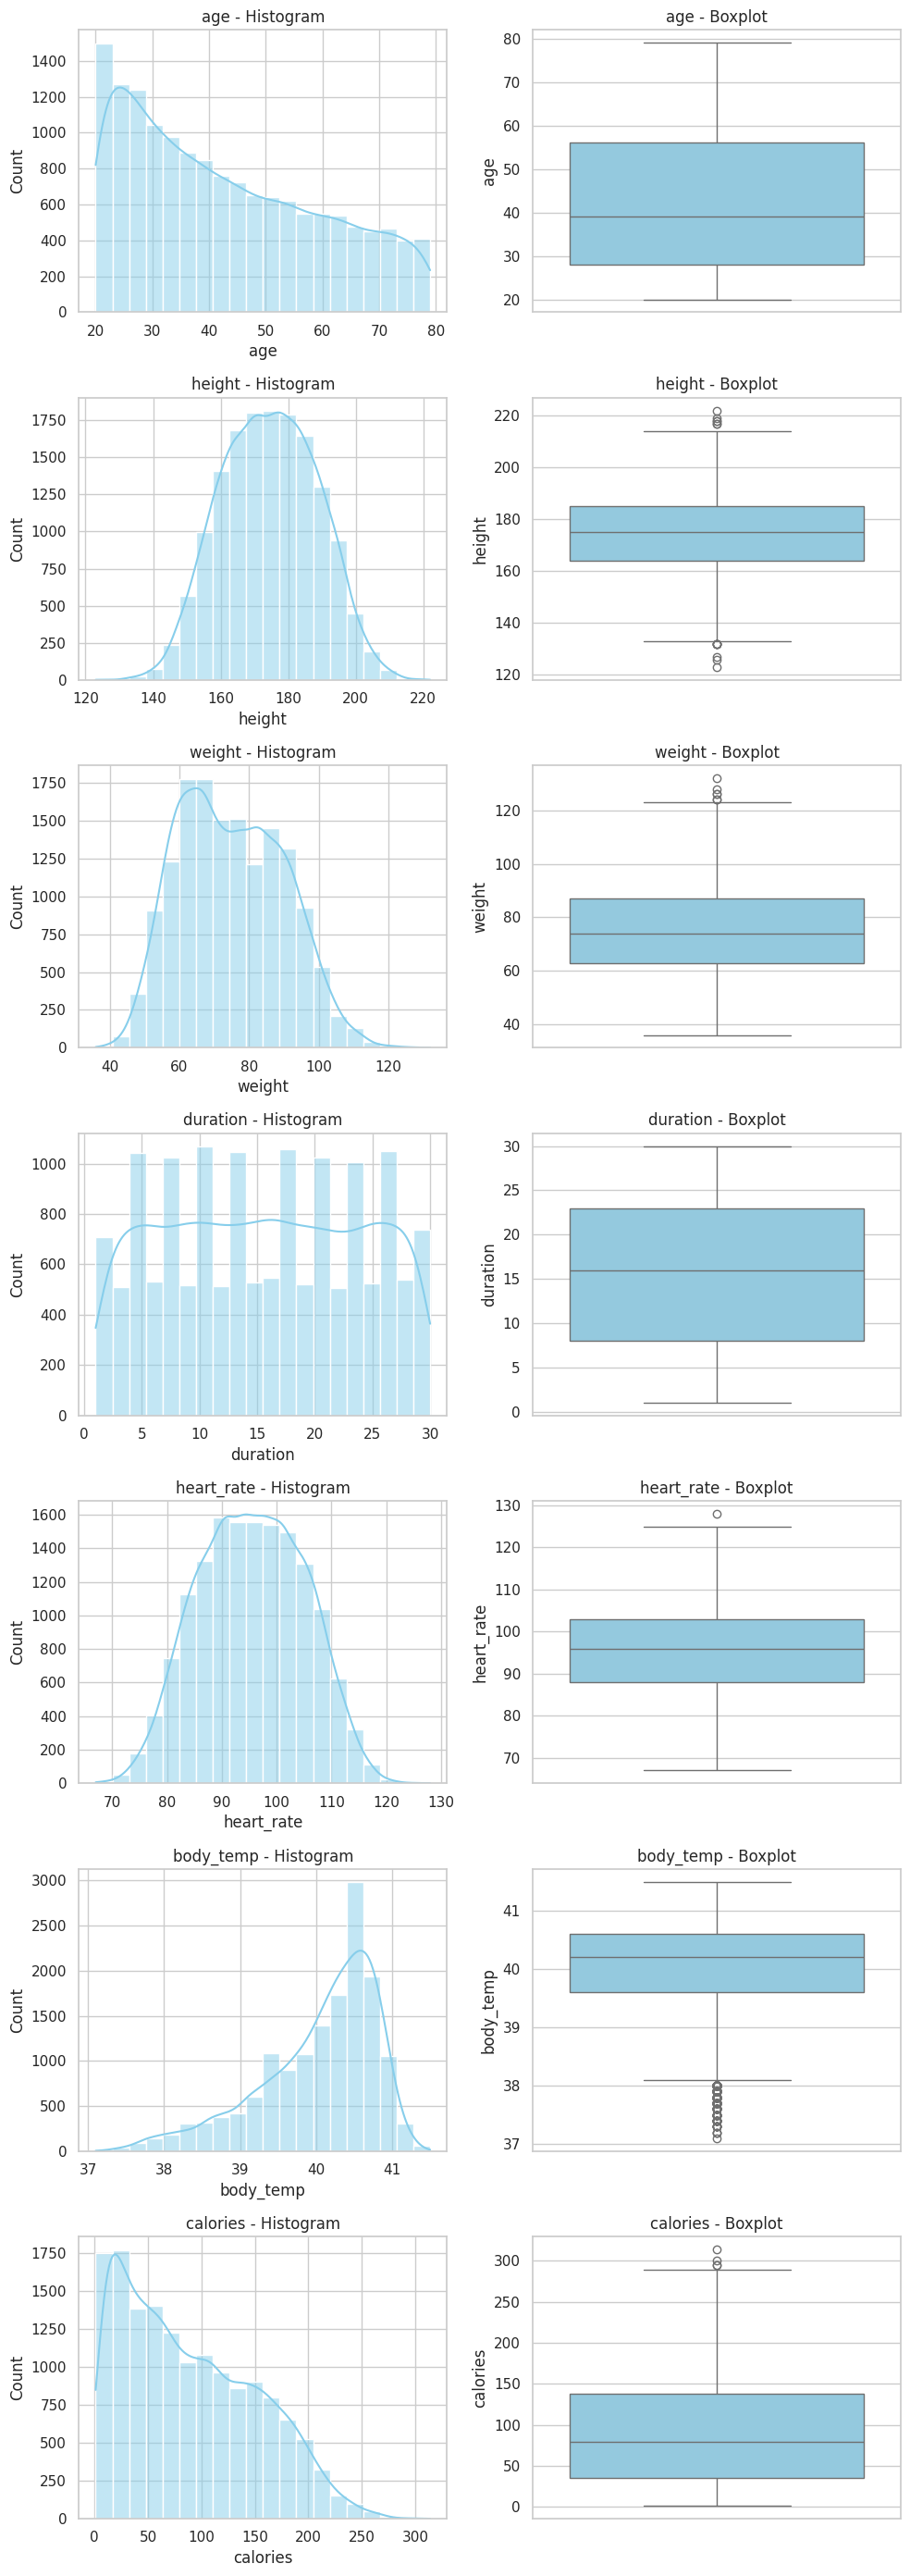

In [15]:
# Do the general plots of data distributions

# Select numeric columns
numeric_cols = df1.select_dtypes(include=[np.number]).columns
# numeric_cols = [col for col in numeric_cols if col != 'user_id']

# Subplot config
n_cols = 2  # Histogram and Boxplot
n_rows = len(numeric_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
sns.set(style="whitegrid")

# Ensure axes is 2D for consistency
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Plot for each column
for i, col in enumerate(numeric_cols):
    # Histogram on the left
    sns.histplot(df1[col], color='skyblue', bins=20, kde=True, ax=axes[i][0])
    axes[i][0].set_title(f'{col} - Histogram')

    # Boxplot on the right
    sns.boxplot(y=df1[col], color='skyblue', ax=axes[i][1])
    axes[i][1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()


## Data Wrangling

In [16]:
# Create an age group column
bins = [19, 29, 39, 49, 59, 69, 79]
labels = ['20–29', '30–39', '40–49', '50–59', '60–69', '70–79']

df1['age_group'] = pd.cut(df1['age'], bins=bins, labels=labels, right=True)

In [17]:
numeric_cols

Index(['age', 'height', 'weight', 'duration', 'heart_rate', 'body_temp',
       'calories'],
      dtype='object')

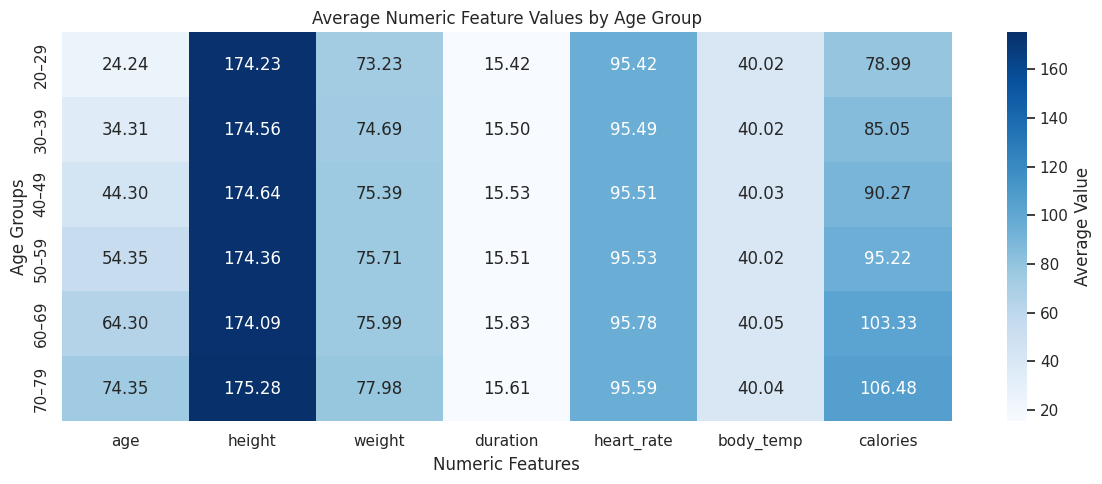

In [18]:
# Compare age groups vs numeric features
avg_by_age_group = df1.groupby('age_group')[numeric_cols].mean().round(2)

plt.figure(figsize=(12, 5))
sns.heatmap(avg_by_age_group, annot=True, cmap='Blues', fmt='.2f', cbar_kws={'label': 'Average Value'})
plt.title('Average Numeric Feature Values by Age Group')
plt.ylabel('Age Groups')
plt.xlabel('Numeric Features')
plt.tight_layout()
plt.show()

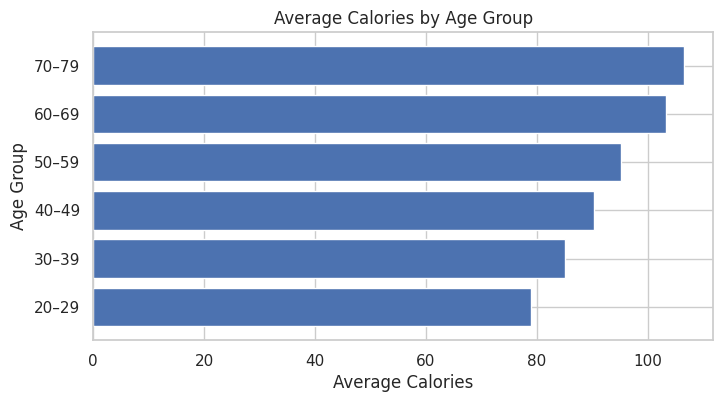

In [19]:
# Plot a barh of age-group ve calories
age_vs_calories = df1.groupby('age_group')['calories'].mean()

plt.figure(figsize=(8, 4))
plt.barh(age_vs_calories.index, age_vs_calories.values)
plt.xlabel('Average Calories')
plt.ylabel('Age Group')
plt.title('Average Calories by Age Group')
plt.show()

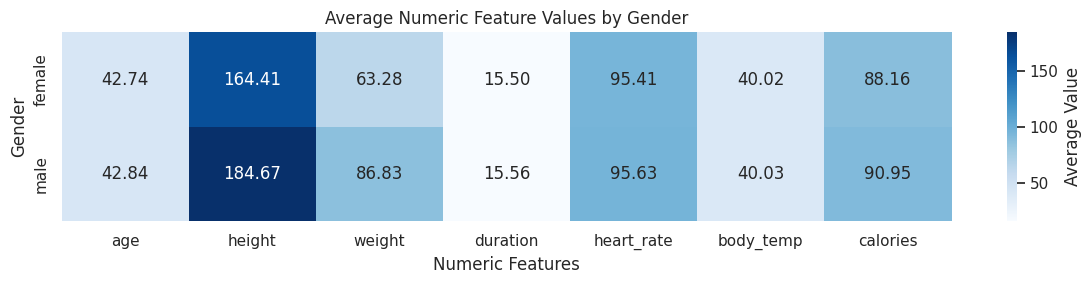

In [20]:
# Compare gender vs numeric features
avg_by_gender = df1.groupby('gender')[numeric_cols].mean().round(2)

plt.figure(figsize=(12, 3))
sns.heatmap(avg_by_gender, annot=True, cmap='Blues', fmt='.2f', cbar_kws={'label': 'Average Value'})
plt.title('Average Numeric Feature Values by Gender')
plt.ylabel('Gender')
plt.xlabel('Numeric Features')
plt.tight_layout()
plt.show()

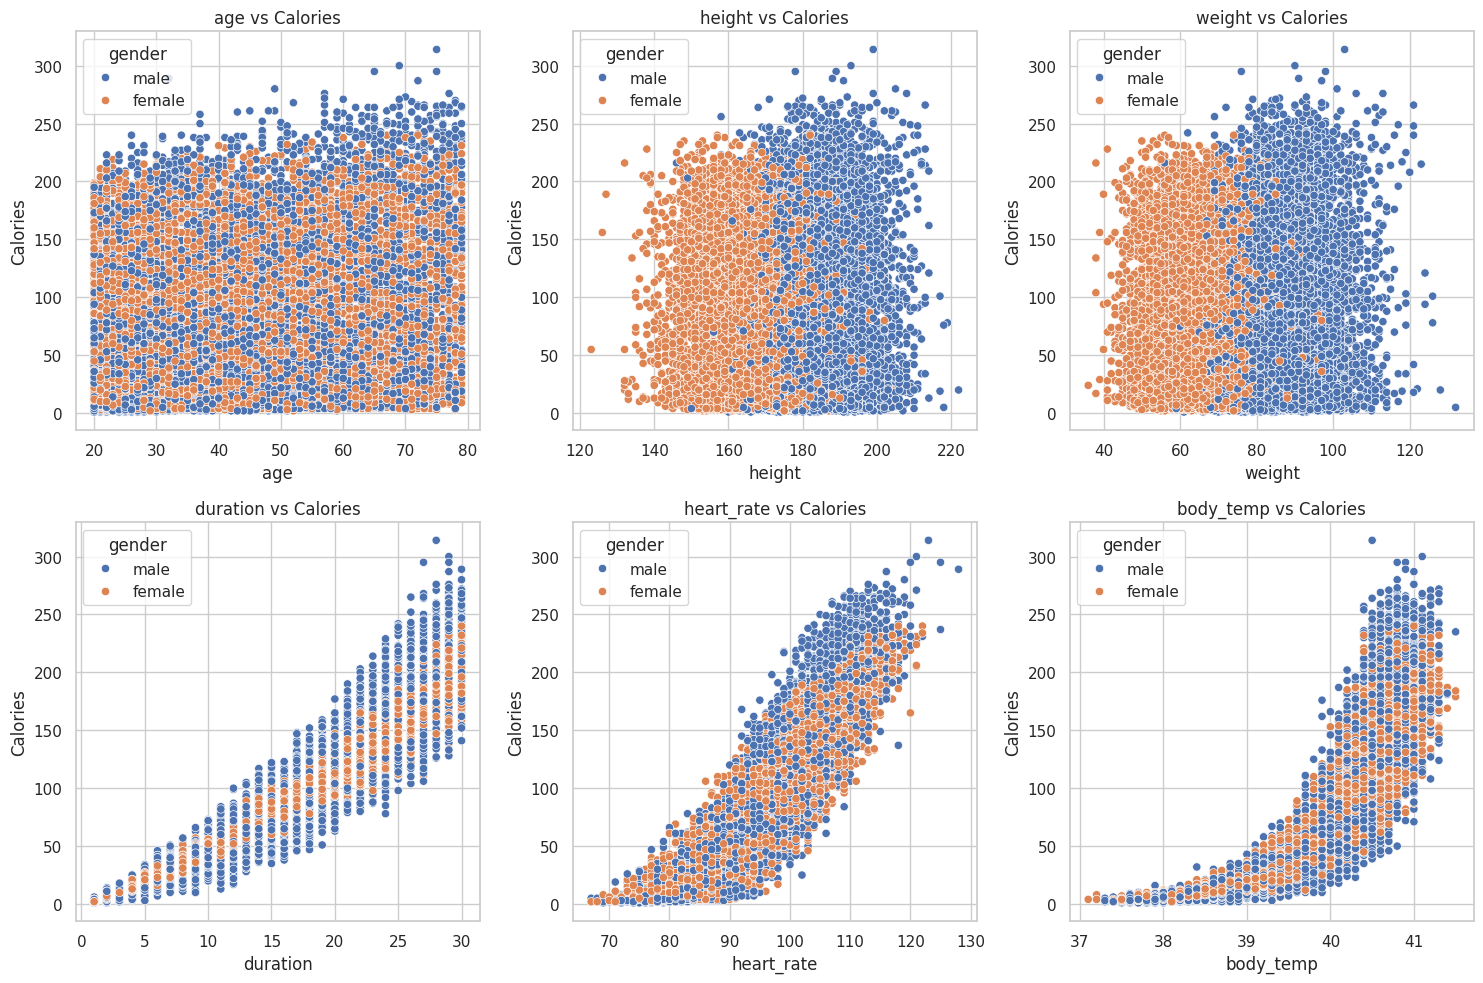

In [21]:
# Plotting Feature variables vs Target

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
num_cols = ['age', 'height', 'weight', 'duration', 'heart_rate', 'body_temp']

for i, col in enumerate(num_cols):
    sns.scatterplot(data=df1, x=col, y='calories', hue='gender', ax=axes[i])
    axes[i].set_title(f'{col} vs Calories')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Calories')

plt.tight_layout()
plt.show()

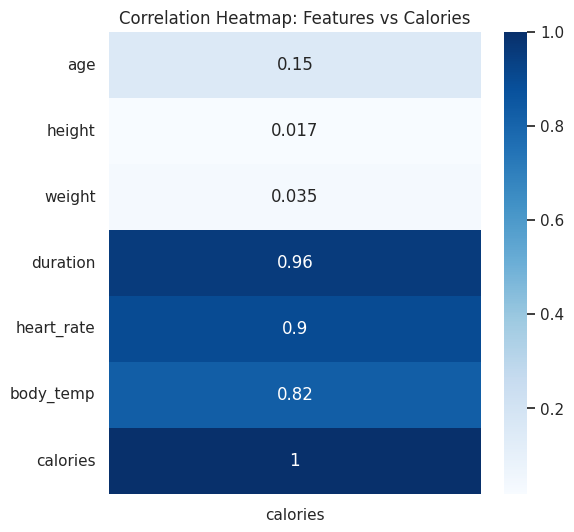

In [22]:
# Calculation correlation of Features vs Calories
corr_df = df1[numeric_cols].corr()['calories'].to_frame()

# Plot a correlation heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(corr_df, annot=True, cmap='Blues')
plt.title('Correlation Heatmap: Features vs Calories')
plt.show()

## One-Hot Encode Nominal Variable (`Gender`)

In [23]:
# Encode Gender
df = pd.get_dummies(columns=['gender'], data=df1, drop_first=True)


In [24]:
df.head(3)

,age,height,weight,duration,heart_rate,body_temp,calories,age_group,gender_male
0,68,190.0,94.0,29.0,105.0,40.8,231.0,60–69,True
1,20,166.0,60.0,14.0,94.0,40.3,66.0,20–29,False
2,69,179.0,79.0,5.0,88.0,38.7,26.0,60–69,True


In [25]:
# Convert bool values to int
df['gender_male'] = df['gender_male'].astype(int)

df.head(3)

,age,height,weight,duration,heart_rate,body_temp,calories,age_group,gender_male
0,68,190.0,94.0,29.0,105.0,40.8,231.0,60–69,1
1,20,166.0,60.0,14.0,94.0,40.3,66.0,20–29,0
2,69,179.0,79.0,5.0,88.0,38.7,26.0,60–69,1


## Label Encode Ordinal Variable (`Age_Group`)

In [26]:
df.age_group.unique()

['60–69', '20–29', '30–39', '40–49', '50–59', '70–79']
Categories (6, object): ['20–29' < '30–39' < '40–49' < '50–59' < '60–69' < '70–79']

In [27]:
# Create a mapping dict
mapping_dict = {'20–29': 1, '30–39': 2, '40–49': 3, '50–59': 4, '60–69': 5, '70–79': 6}

# Encode age groups
df['age_group'] = df['age_group'].map(mapping_dict)

df.age_group.unique()

[5, 1, 2, 3, 4, 6]
Categories (6, int64): [1 < 2 < 3 < 4 < 5 < 6]

In [28]:
df.columns

Index(['age', 'height', 'weight', 'duration', 'heart_rate', 'body_temp',
       'calories', 'age_group', 'gender_male'],
      dtype='object')

## Train a Linear Regression Model

In [29]:
# Create X and Y
X = df.drop(columns='calories', axis='columns')
y = df['calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale X_train and X_test
scaler = MinMaxScaler()

cols_to_scale = ['age', 'height', 'weight', 'duration', 'heart_rate', 'body_temp', 'age_group']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [30]:
print([X_train.shape, X_test.shape])

[(11999, 8), (3000, 8)]


In [31]:
X_train.head(3)

,age,height,weight,duration,heart_rate,body_temp,age_group,gender_male
9838,0.355932,0.572917,0.489583,0.827586,0.827586,0.772727,0.4,1
7689,0.542373,0.552083,0.427083,0.862069,0.775862,0.840909,0.6,1
6557,0.033898,0.552083,0.312500,0.379310,0.379310,0.727273,0.0,0


In [33]:
# Train a Linear Regression model
lr = LinearRegression()

lr.fit(X_train, y_train)

train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print(f"Train Score: {round(train_score, 3)}, Test Score: {round(test_score, 3)}")

Train Score: 0.967, Test Score: 0.966


In [34]:
# Calculate r2 score and mean_sqr_error
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2 Score: {round(r2, 3)}, MSE: {round(mse, 3)}, RMSE: {round(rmse, 3)}")

R2 Score: 0.966, MSE: 130.486, RMSE: 11.423


In [35]:
# Inspect Model coefficient and intercept
for feature, coef in zip(X_train.columns, lr.coef_.ravel()):
    print(f"{feature}: {coef:.4f}")

print(f"\nModel intercept: {lr.intercept_}")

age: 25.9326
height: -19.1538
weight: 30.8836
duration: 192.6360
heart_rate: 115.0443
body_temp: -74.5006
age_group: 3.0024
gender_male: -1.4702

Model intercept: -26.651469887634036


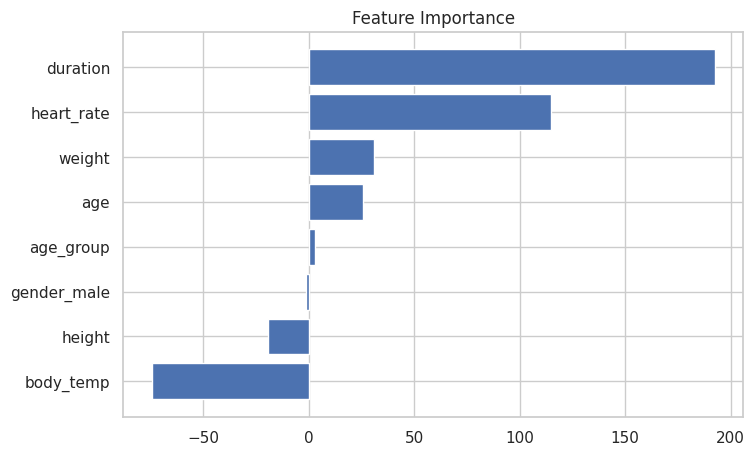

In [37]:
# Inspect Feature Importance

feature_importance = lr.coef_

coef_df = pd.DataFrame(feature_importance, index=X_test.columns, columns=['coefficient']).sort_values(by='coefficient', ascending=True)

# Plot the coef_df on barh to visualize feature importance

plt.figure(figsize=(8, 5))
plt.barh(y=coef_df.index, width=coef_df['coefficient'])
plt.title('Feature Importance')
#plt.tight_layout()
plt.show()

## Calculate VIF

In [38]:
# Calculate VIF

def calculate_vif(data):
    # Drop any non-numeric columns
    data = data.select_dtypes(include=[np.number])

    # Drop rows with NaNs (or fill them if appropriate)
    data = data.dropna()

    vif_df = pd.DataFrame()
    vif_df['features'] = data.columns
    vif_df['vif_values'] = [vif(data.values, i) for i in range(data.shape[1])]

    return vif_df


calculate_vif(X_train)

,features,vif_values
0,age,94.585717
1,height,147.565470
2,weight,125.826083
3,duration,21.806817
4,heart_rate,31.697297
5,body_temp,51.246206
6,age_group,76.051522
7,gender_male,5.558035


In [39]:
# Drop height column
X_train_updated = X_train.drop(columns=['height'], axis='columns')
X_test_updated = X_test.drop(columns=['height'], axis='columns')

In [40]:
# Recalculate VIF
calculate_vif(X_train_updated)

,features,vif_values
0,age,94.277210
1,weight,17.160117
2,duration,17.876055
3,heart_rate,30.255103
4,body_temp,40.156258
5,age_group,75.388197
6,gender_male,4.909567


In [41]:
# Drop Age column
X_train_updated.drop(columns=['age'], axis='columns', inplace=True)
X_test_updated.drop(columns=['age'], axis='columns', inplace=True)

# Recalculate VIF
calculate_vif(X_train_updated)

,features,vif_values
0,weight,16.981882
1,duration,17.217799
2,heart_rate,30.003296
3,body_temp,38.235348
4,age_group,2.247384
5,gender_male,4.892591


In [42]:
# Drop Body-temp column
X_train_updated.drop(columns=['body_temp'], axis='columns', inplace=True)
X_test_updated.drop(columns=['body_temp'], axis='columns', inplace=True)

# Recalculate VIF
calculate_vif(X_train_updated)

,features,vif_values
0,weight,13.010164
1,duration,13.238588
2,heart_rate,22.905371
3,age_group,2.223783
4,gender_male,4.555258


In [43]:
# Drop Heart_Rate column
X_train_updated.drop(columns=['heart_rate'], axis='columns', inplace=True)
X_test_updated.drop(columns=['heart_rate'], axis='columns', inplace=True)

# Recalculate VIF
calculate_vif(X_train_updated)

,features,vif_values
0,weight,8.873278
1,duration,3.134003
2,age_group,2.195829
3,gender_male,4.230316


In [44]:
# Train a Linear Regression model
lr2 = LinearRegression()

lr2.fit(X_train_updated, y_train)

train_score = lr2.score(X_train_updated, y_train)
test_score = lr2.score(X_test_updated, y_test)

print(f"Train Score: {round(train_score, 3)}, Test Score: {round(test_score, 3)}")

Train Score: 0.934, Test Score: 0.931


In [45]:
# Calculate r2 score and mean_sqr_error
y_pred = lr2.predict(X_test_updated)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2 Score: {round(r2, 3)}, MSE: {round(mse, 3)}, RMSE: {round(rmse, 3)}")

R2 Score: 0.931, MSE: 265.69, RMSE: 16.3


In [46]:
# Inspect Model coefficient and intercept
for feature, coef in zip(X_train_updated.columns, lr2.coef_.ravel()):
    print(f"{feature}: {coef:.4f}")

print(f"\nModel intercept: {lr2.intercept_}")

weight: 11.0748
duration: 207.4300
age_group: 25.8151
gender_male: -0.4470

Model intercept: -28.11606363261332


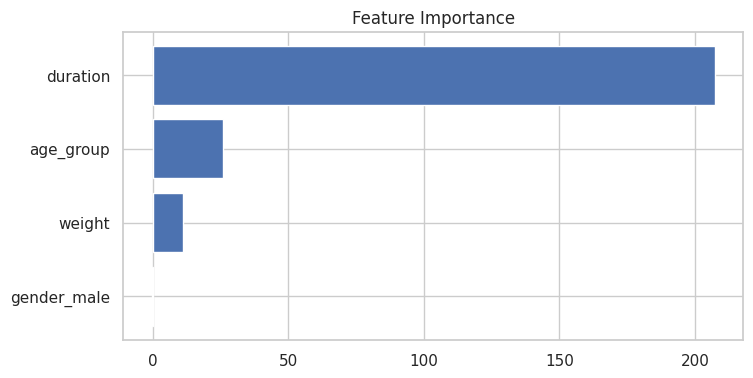

In [47]:
# Inspect Feature Importance

feature_importance = lr2.coef_

coef_df = pd.DataFrame(feature_importance, index=X_test_updated.columns, columns=['coefficient']).sort_values(by='coefficient', ascending=True)

# Plot the coef_df on barh to visualize feature importance

plt.figure(figsize=(8, 4))
plt.barh(y=coef_df.index, width=coef_df['coefficient'])
plt.title('Feature Importance')
#plt.tight_layout()
plt.show()

## Train an XGBoost Model

In [60]:
# Train an XGBoost model

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)

xgb.fit(X_train, y_train)

train_score = xgb.score(X_train, y_train)
test_score = xgb.score(X_test, y_test)

print(f"Train Score: {round(train_score, 3)}, Test Score: {round(test_score, 3)}")

Train Score: 0.999, Test Score: 0.999


In [61]:
# Calculate r2 score and mean_sqr_error
y_pred = xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2 Score: {round(r2, 3)}, MSE: {round(mse, 3)}, RMSE: {round(rmse, 3)}")

R2 Score: 0.999, MSE: 4.417, RMSE: 2.102


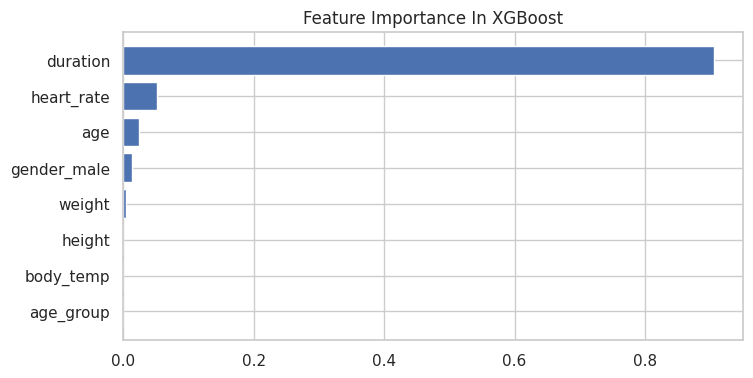

In [52]:
# Inspect Feature Importance

feature_importance = xgb.feature_importances_

coef_df = pd.DataFrame(feature_importance, index=X_test.columns, columns=['coefficient']).sort_values(by='coefficient', ascending=True)

# Plot the coef_df on barh to visualize feature importance

plt.figure(figsize=(8, 4))
plt.barh(y=coef_df.index, width=coef_df['coefficient'])
plt.title('Feature Importance In XGBoost')
#plt.tight_layout()
plt.show()

## Error Analysis of XGB Model

In [62]:
# Error Analysis for the best XGBoost model
y_pred = xgb.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals*100)/y_test

# Create a df
results_df = pd.DataFrame({'actual': y_test,
                           'predicted': y_pred,
                           'residuals': residuals,
                           'residuals_pct': residuals_pct})

results_df.head()

,actual,predicted,residuals,residuals_pct
6723,203.0,207.422607,4.422607,2.178624
6473,223.0,223.821411,0.821411,0.368346
4679,6.0,5.585059,-0.414941,-6.915681
862,161.0,161.883377,0.883377,0.548681
7286,86.0,84.503220,-1.496780,-1.740442


In [63]:
results_df[['residuals', 'residuals_pct']].describe()

,residuals,residuals_pct
count,3000.000000,3000.000000
mean,0.018046,0.106107
std,2.101890,9.071328
min,-31.586365,-262.308681
25%,-0.998176,-1.420970
50%,0.082195,0.112498
75%,1.052772,1.590762
max,13.795288,89.508164


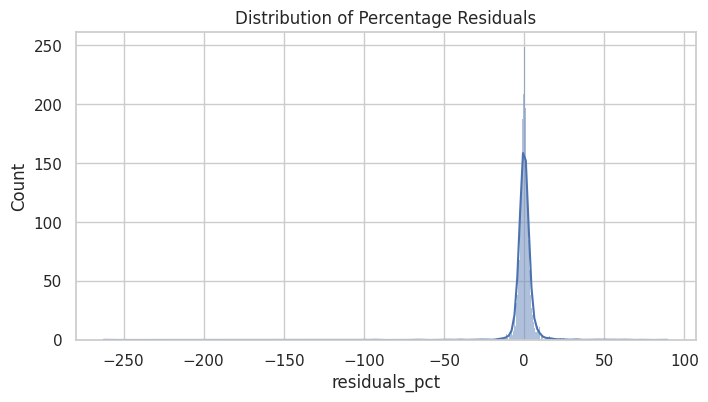

In [64]:
# Plot a histogram of the percentage residuals
plt.figure(figsize=(8, 4))
sns.histplot(data=results_df, x='residuals_pct', kde=True)
plt.title('Distribution of Percentage Residuals')
plt.show()

In [65]:
# Find results that are more than 10% of the actual
extreme_error_threshold = 10

extreme_results_df = results_df[np.abs(results_df['residuals_pct']) > extreme_error_threshold]

extreme_results_df.shape

(112, 4)

In [66]:
# Percentage of extreme errors

pct_extreme_error = extreme_results_df.shape[0] / results_df.shape[0] * 100

pct_extreme_error

3.733333333333334

In [ ]:
# Most severe errors
results_df[np.abs(results_df['residuals_pct']) > 50].sort_values(by='residuals_pct', ascending=False)

In [68]:
X_test.index

Index([ 6723,  6473,  4679,   862,  7286,  8127,  3017,  3087,  6425,  2250,
       ...
        8719,   856,  9822,  3944,  8192,  3297, 14114,  5514,  9939, 14347],
      dtype='int64', length=3000)

In [69]:
# Find the index of datapoints with extreme errors
extreme_results_df.index


Index([ 4923,  2864,  4096,  4400,  1121,  8206, 14382,  8992,  1270,  2390,
       ...
       11753, 14749, 12358,  8637,  8489,  8083, 13567,  5173,  2058,  4191],
      dtype='int64', length=112)

In [70]:
# Find rows with extreme results from X_test

extreme_errors_df = X_test.loc[extreme_results_df.index]

extreme_errors_df.head()

,age,height,weight,duration,heart_rate,body_temp,age_group,gender_male
4923,0.067797,0.572917,0.427083,0.000000,0.155172,0.204545,0.0,1
2864,0.813559,0.447917,0.364583,0.068966,0.000000,0.363636,0.8,1
4096,0.423729,0.562500,0.375000,0.034483,0.137931,0.272727,0.4,0
4400,0.169492,0.427083,0.312500,0.000000,0.000000,0.227273,0.2,0
1121,0.050847,0.520833,0.437500,0.068966,0.362069,0.363636,0.0,1


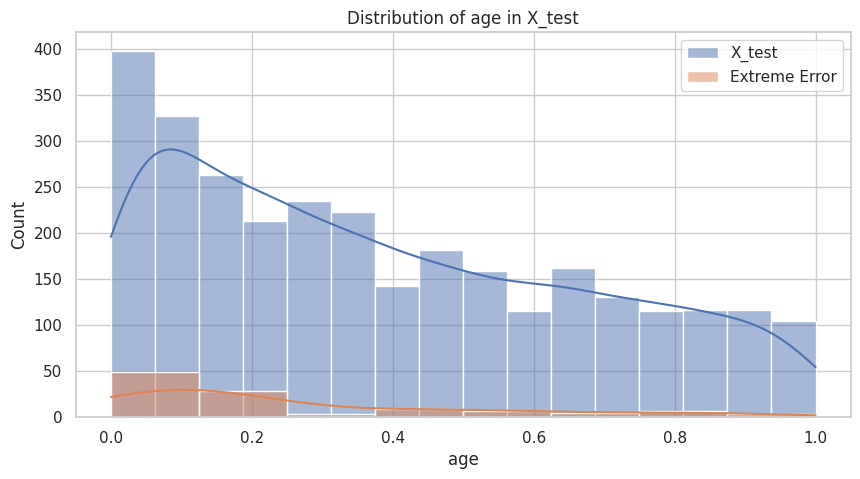

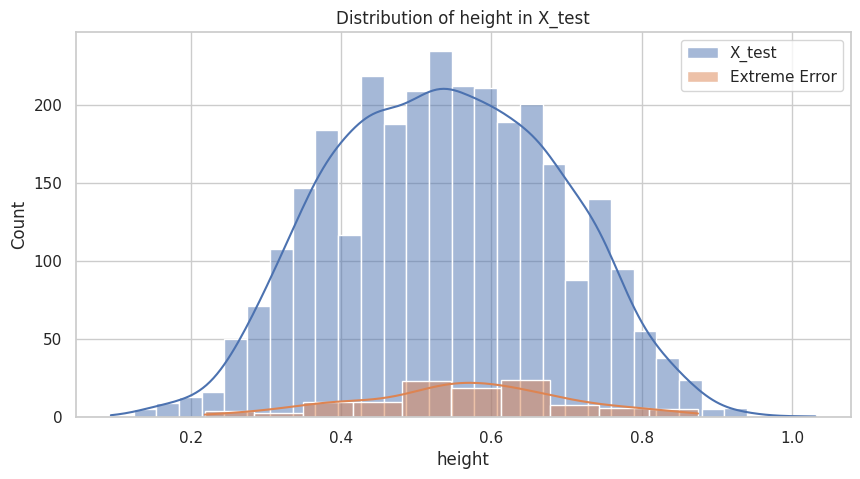

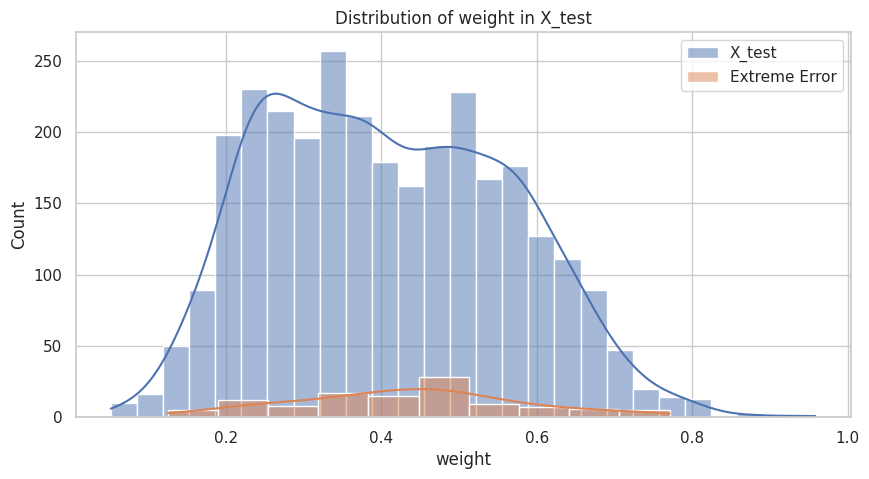

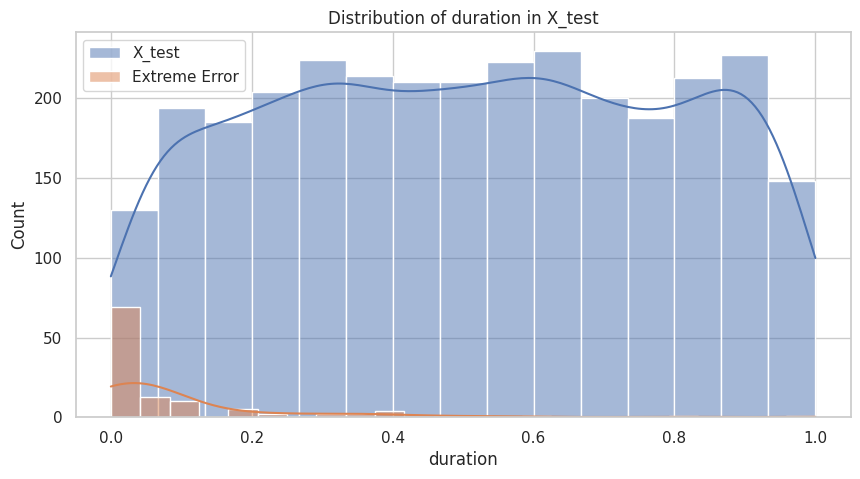

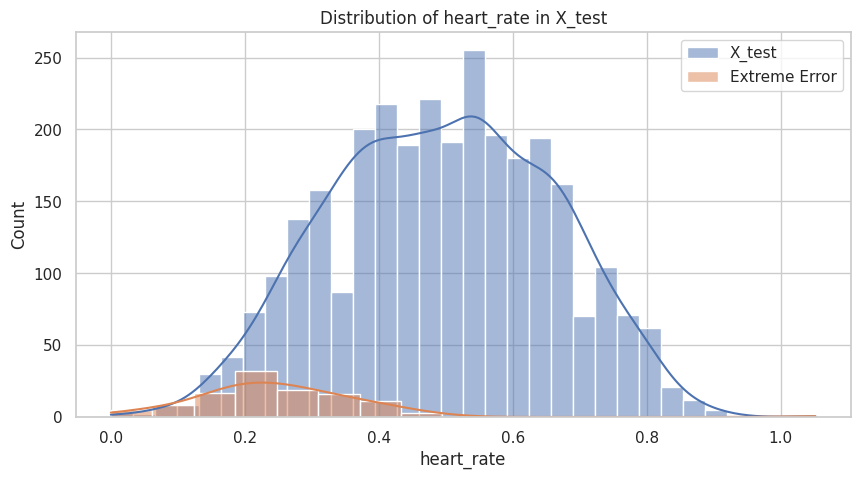

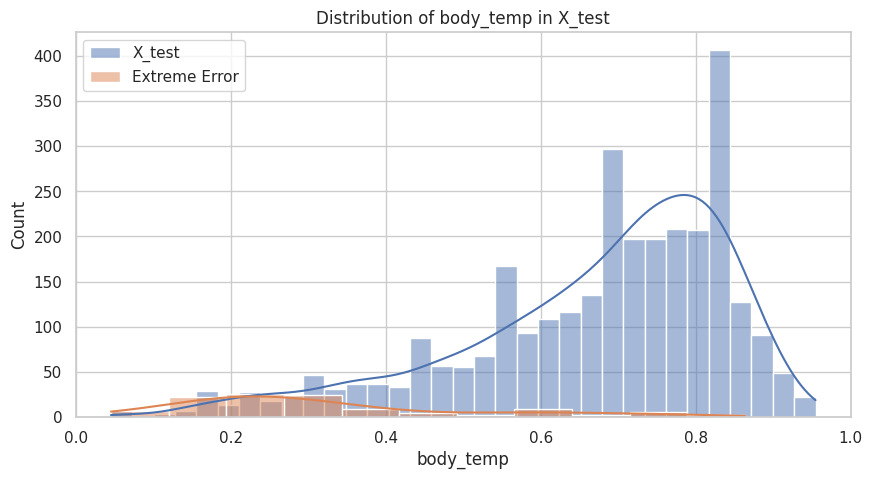

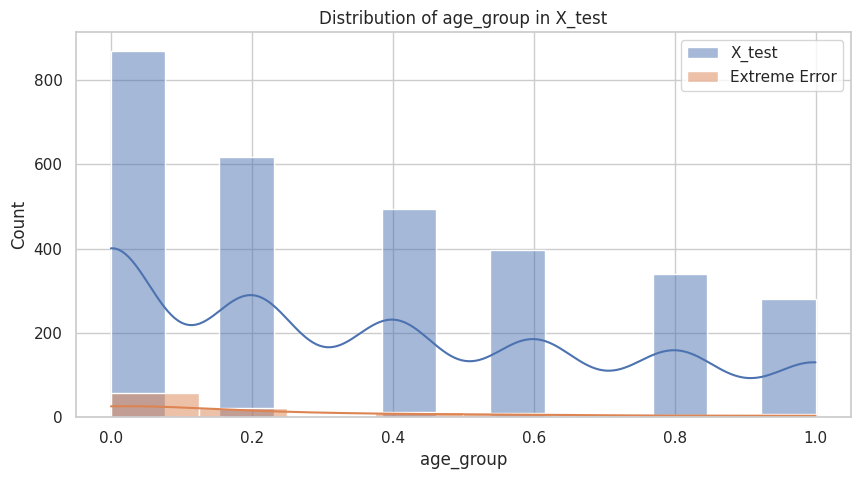

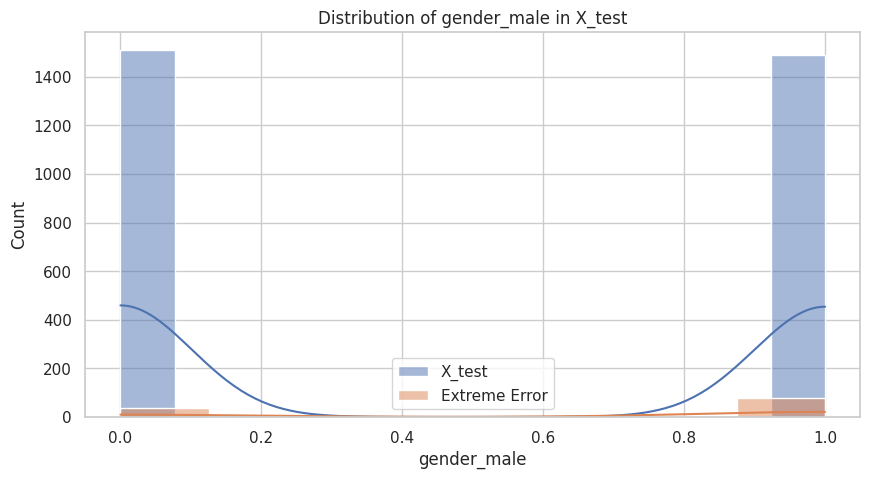

In [71]:
# Plot the distribution of the X_test and extreme_errors_df side by side for comparison
for feature in X_test.columns:
    plt.figure(figsize=(10, 5))
    #plt.subplot(1, 2, 1)
    sns.histplot(X_test[feature], kde=True, label='X_test')
    sns.histplot(extreme_errors_df[feature], kde=True, label='Extreme Error')
    plt.title(f'Distribution of {feature} in X_test')
    plt.legend()

    # plt.subplot(1, 2, 2)
    # sns.histplot(extreme_errors_df[feature], kde=True, label='extreme_errors_df')
    # plt.title(f'Distribution of {feature} in extreme_errors_df')
    # plt.legend()

    # plt.tight_layout()
    plt.show()

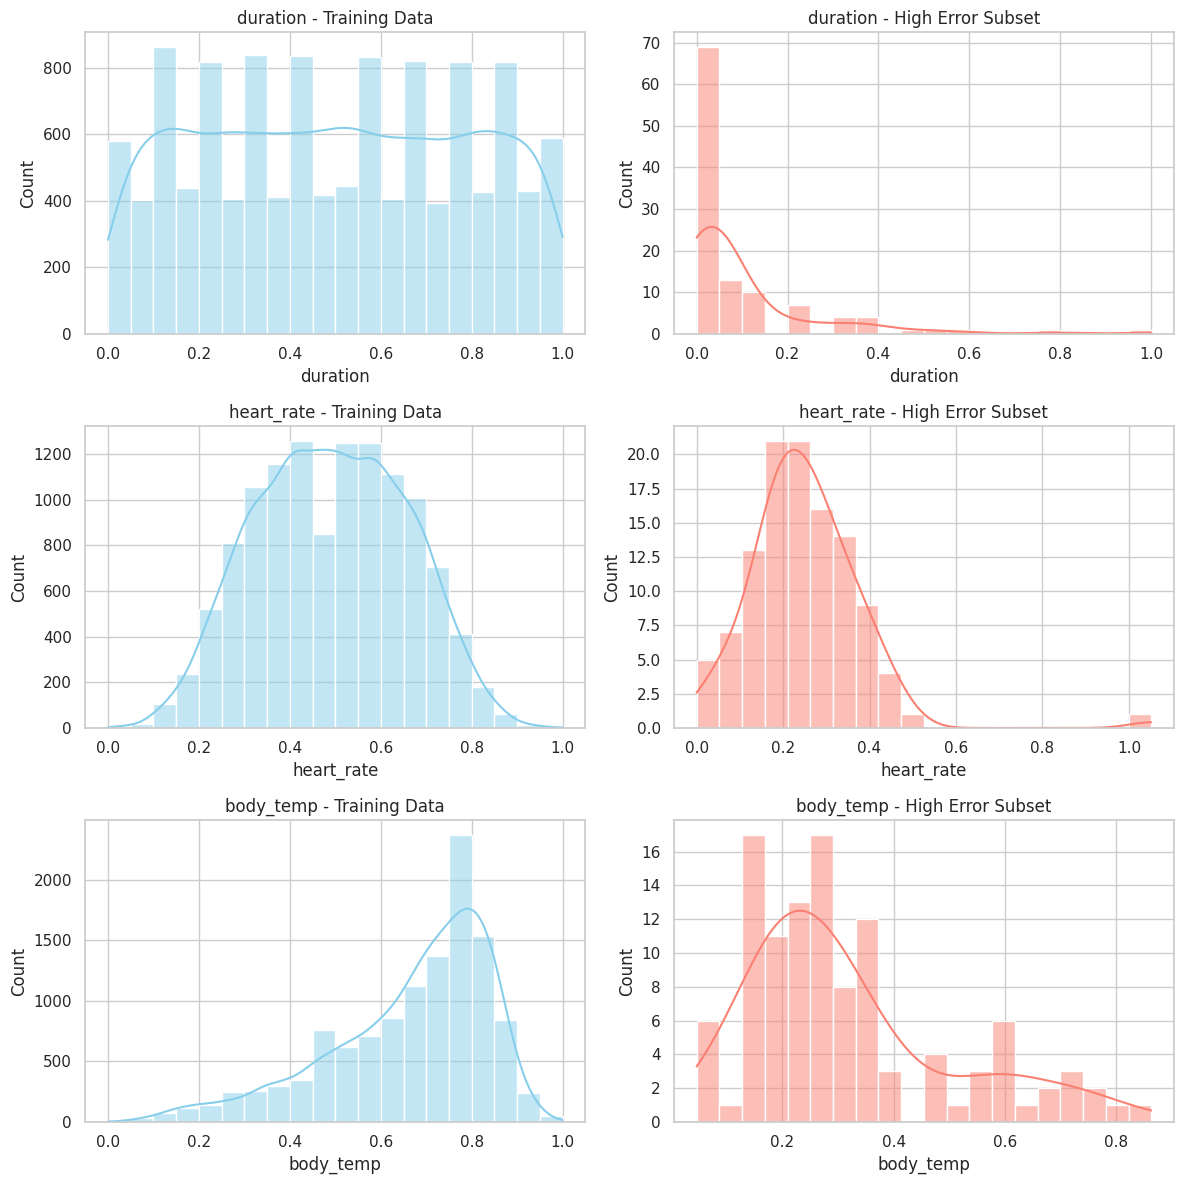

In [72]:
# Example: List of columns to compare
cols_to_plot = ['duration', 'heart_rate', 'body_temp']  # Replace with actual column names

# Set up subplot grid: 3 rows, 2 columns (df1 left, df2 right)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
sns.set(style="whitegrid")

for i, col in enumerate(cols_to_plot):
    # Left: df1
    sns.histplot(X_train[col], kde=True, color='skyblue', bins=20, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Training Data')

    # Right: df2
    sns.histplot(extreme_errors_df[col], kde=True, color='salmon', bins=20, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - High Error Subset')

# Improve layout
plt.tight_layout()
plt.show()


### Key Observation
- It looks like the model performed the worst on data with low duration, I'll separate this from the entire dataset and do a model segmentation.

# Model Segmentation

In [8]:
duration_less_than_10 = df1[df1['duration'] <= 10]
duration_more_than_10 = df1[df1['duration'] > 10]

In [74]:
print(f"Number of entries with low duration: {duration_less_than_10.shape}\n")
print(f"Number of entries with high duration: {duration_more_than_10.shape}")

Number of entries with low duration: (4873, 9)

Number of entries with high duration: (10126, 9)


## Data Validation
- Inspect heart rate vs body temp vs calories burned for duration <= 10, and filter off suspicious data.

In [75]:
duration_less_than_10.describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,4873.000000,4873.000000,4873.000000,4873.000000,4873.000000,4873.000000,4873.000000
mean,42.759286,174.446747,74.879951,5.819003,85.946850,39.115145,24.117381
std,16.951555,14.274149,15.044384,2.730971,5.669453,0.615875,14.298475
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,3.000000,82.000000,38.700000,12.000000
50%,40.000000,174.000000,74.000000,6.000000,86.000000,39.200000,22.000000
75%,56.000000,185.000000,87.000000,8.000000,90.000000,39.600000,34.000000
max,79.000000,222.000000,132.000000,10.000000,106.000000,40.400000,73.000000


### Investigating entries with `body_temp` greater than or equal 40

In [76]:
duration_less_than_10[duration_less_than_10['body_temp'] >= 40].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,44.587065,176.328358,76.542289,9.522388,89.736318,40.065174,43.174129
std,18.005378,15.095087,15.961499,0.671376,5.015488,0.087069,10.234966
min,20.000000,139.000000,42.000000,8.000000,79.000000,40.000000,18.000000
25%,28.000000,164.000000,64.000000,9.000000,86.000000,40.000000,37.000000
50%,40.000000,176.000000,75.000000,10.000000,90.000000,40.000000,43.000000
75%,61.000000,188.000000,90.000000,10.000000,93.000000,40.100000,50.000000
max,79.000000,210.000000,116.000000,10.000000,106.000000,40.400000,73.000000


- Reaching 40°C in 8-10 minutes would require extreme exertion, high ambient temperature/humidity, and likely dehydration or medical impairment.

- If body temp is very high (e.g., above 39), heart rate should also reflect heavy exertion — typically 140–180 bpm, not 79–106 bpm.

- I'll replace `body_temp >= 40` with a more realistic temp range (e.g., 37.0–38.5°C) based on weight, HR, and duration.

In [80]:
duration_less_than_10[duration_less_than_10['body_temp'] >= 40].shape

(201, 9)

In [12]:
# For duration <= 10, replace body_temp > 39.5
duration_less_than_10.loc[duration_less_than_10['body_temp'] >= 40, 'body_temp'] = np.random.uniform(37.2, 38.5, size=201)


In [82]:
duration_less_than_10[duration_less_than_10['body_temp'] >= 40].shape

(0, 9)

### Investigate entries with`calories` less than 12

In [ ]:
duration_less_than_10[duration_less_than_10['calories'] < 12].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,1137.000000,1137.000000,1137.000000,1137.000000,1137.000000,1137.000000,1137.000000
mean,38.358839,175.649077,75.724714,2.378188,81.138962,38.297449,7.003518
std,15.466046,13.772516,14.472741,1.134983,4.756208,0.462581,2.733141
min,20.000000,136.000000,41.000000,1.000000,67.000000,37.100000,1.000000
25%,26.000000,165.000000,64.000000,2.000000,78.000000,38.000000,5.000000
50%,34.000000,176.000000,76.000000,2.000000,81.000000,38.300000,7.000000
75%,48.000000,186.000000,87.000000,3.000000,84.000000,38.600000,9.000000
max,79.000000,218.000000,132.000000,9.000000,96.000000,39.900000,11.000000


In [84]:
# Inspect rows with duration < 5, calories > 10, temp > 39, hr < 100
duration_less_than_10[(duration_less_than_10['duration'] < 5) & (duration_less_than_10['calories'] > 10) & (duration_less_than_10['body_temp'] > 39) & (duration_less_than_10['heart_rate'] < 100)].shape



(113, 9)

The above 113 entries look suspicious because high temp & calories with low HR in a very short session is implausible.

These entries are likely erroneous, simulated poorly, or sensor issues.

In [14]:
# Dropping these rows
drop_mask = (duration_less_than_10['duration'] < 5) & (duration_less_than_10['calories'] > 10) & (duration_less_than_10['body_temp'] > 39) & (duration_less_than_10['heart_rate'] < 100)
duration_less_than_10 = duration_less_than_10[~drop_mask]


In [86]:
# Inspect rows with duration < 5, calories < 10, temp > 39, hr < 100
duration_less_than_10[(duration_less_than_10['duration'] < 5) & (duration_less_than_10['calories'] < 10) & (duration_less_than_10['body_temp'] > 39) & (duration_less_than_10['heart_rate'] < 100)].shape



(19, 9)

High temp (> 39) + low HR (< 100) = doesn’t align even with light activity

In [15]:
# Fixing the body temperature
fix_mask = (duration_less_than_10['duration'] < 5) & (duration_less_than_10['calories'] < 10) & (duration_less_than_10['body_temp'] > 39) & (duration_less_than_10['heart_rate'] < 100)
duration_less_than_10.loc[fix_mask, 'body_temp'] = np.random.uniform(37.4, 38.3, size=fix_mask.sum())


In [88]:
# Inspect rows with duration < 5, calories > 10, temp > 39, hr< 100
duration_less_than_10[(duration_less_than_10['duration'] > 5) & (duration_less_than_10['calories'] > 10) & (duration_less_than_10['body_temp'] > 39) & (duration_less_than_10['heart_rate'] > 100)].shape



(24, 9)

- A body temp >39.5°C indicates severe overheating, which requires HR >130–150 bpm and much longer exertion or external heat.

- HR of 100–103 bpm reflects light exercise, maybe a brisk walk — not enough to hit up to 39.9°C.

- Only 6–10 mins duration isn’t sufficient to build that much heat without extreme conditions.

In [16]:
# Fixing the body temperature
duration_less_than_10.loc[(duration_less_than_10['body_temp'] > 39.2) & (duration_less_than_10['heart_rate'] < 110), 'body_temp'] = np.random.uniform(37.3, 38.5)


In [90]:
duration_less_than_10.describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,4760.000000,4760.000000,4760.000000,4760.000000,4760.000000,4760.000000,4760.000000
mean,42.783824,174.479412,74.907773,5.863445,85.974580,38.111786,24.324160
std,16.980865,14.238210,14.998372,2.747527,5.681945,0.602794,14.397158
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,3.000000,82.000000,37.599719,12.000000
50%,40.000000,175.000000,74.000000,6.000000,86.000000,37.700000,23.000000
75%,56.000000,185.000000,87.000000,8.000000,90.000000,38.700000,35.000000
max,79.000000,222.000000,132.000000,10.000000,106.000000,39.200000,73.000000


Inspect entries with`calories` less than 3

In [91]:
duration_less_than_10[duration_less_than_10['calories'] < 3].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,29.862069,180.741379,81.189655,1.224138,75.741379,37.846552,1.793103
std,9.435744,11.189846,11.278697,0.531238,3.827694,0.353040,0.408619
min,20.000000,153.000000,55.000000,1.000000,67.000000,37.300000,1.000000
25%,23.000000,175.000000,75.000000,1.000000,74.000000,37.625000,2.000000
50%,27.000000,180.000000,81.000000,1.000000,76.000000,37.800000,2.000000
75%,32.750000,188.750000,85.750000,1.000000,78.000000,38.000000,2.000000
max,59.000000,207.000000,110.000000,3.000000,83.000000,38.900000,2.000000


> The ranges for `duration`, `heart_rate`, and `calories` seem plausible except for `body_temp` which is certainly too high for that range of heart rate and duration.

In [92]:
duration_less_than_10[(duration_less_than_10['body_temp'] > 38.5) & (duration_less_than_10['heart_rate'] < 83)].head()

,gender,age,height,weight,duration,heart_rate,body_temp,calories,age_group
16,male,39,182.0,82.0,4.0,82.0,38.6,11.0,30–39
20,male,67,189.0,93.0,8.0,77.0,39.2,29.0,60–69
22,female,33,157.0,60.0,3.0,80.0,38.7,10.0,30–39
44,female,54,169.0,66.0,3.0,80.0,38.9,11.0,50–59
96,female,57,171.0,74.0,2.0,73.0,38.6,6.0,50–59


High body temperature (> 38.5) requires sustained exertion or external heat stress, and would typically cause HR ≥ 100–130 bpm due to increased cardiovascular demand.

> The combination of short duration (< 10) + low heart rate (< 83) + high body temperature (> 38.5) indicates erroneous data.

In [17]:
# Identify implausible rows
temp_hr_mask = (duration_less_than_10['body_temp'] > 38.5) & (duration_less_than_10['heart_rate'] < 83)

# Adjust body-temp to a realistic range
duration_less_than_10.loc[temp_hr_mask, 'body_temp'] = np.random.uniform(37.3, 38.3, size=temp_hr_mask.sum())

In [94]:
duration_less_than_10[duration_less_than_10['calories'] > 30].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,1572.000000,1572.000000,1572.00000,1572.000000,1572.000000,1572.000000,1572.000000
mean,47.711196,173.887405,74.60687,8.699746,90.407761,37.725827,41.331425
std,17.709641,14.487622,15.52393,1.178062,4.477657,0.401626,7.842268
min,20.000000,123.000000,40.00000,5.000000,77.000000,37.202121,31.000000
25%,32.000000,162.000000,62.00000,8.000000,87.000000,37.599719,35.000000
50%,47.000000,174.000000,73.00000,9.000000,90.000000,37.599719,40.000000
75%,63.000000,185.000000,87.00000,10.000000,93.000000,37.599719,46.000000
max,79.000000,213.000000,121.00000,10.000000,106.000000,39.200000,73.000000


In [95]:
duration_less_than_10[duration_less_than_10['body_temp'] > 38.5].shape

(974, 9)

In [96]:
duration_less_than_10[duration_less_than_10['body_temp'] > 38.5].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000
mean,43.003080,174.288501,74.758727,4.833676,87.564682,38.945791,20.512320
std,17.162215,14.469159,15.109001,1.399257,3.446467,0.201887,7.879837
min,20.000000,132.000000,36.000000,2.000000,83.000000,38.600000,5.000000
25%,28.000000,164.000000,62.000000,4.000000,85.000000,38.800000,15.000000
50%,40.000000,175.000000,74.000000,5.000000,87.000000,39.000000,20.000000
75%,56.000000,185.000000,86.000000,6.000000,90.000000,39.100000,25.000000
max,79.000000,214.000000,121.000000,10.000000,102.000000,39.200000,58.000000


In [97]:
duration_less_than_10[duration_less_than_10['body_temp'] > 39].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000
mean,43.769437,174.302949,75.029491,5.973190,88.292225,39.155228,26.016086
std,17.141110,15.345025,15.835739,1.041778,3.829409,0.049793,7.303318
min,20.000000,132.000000,36.000000,4.000000,83.000000,39.100000,10.000000
25%,29.000000,163.000000,62.000000,5.000000,85.000000,39.100000,22.000000
50%,41.000000,175.000000,75.000000,6.000000,88.000000,39.200000,25.000000
75%,57.000000,186.000000,88.000000,6.000000,91.000000,39.200000,29.000000
max,79.000000,210.000000,121.000000,10.000000,102.000000,39.200000,58.000000


Mild HR (90 bpm) + high temp (39°C) is physiologically inconsistent, unless:
- The person is in a very hot environment
- There's sensor or data error
- The person is ill or overheating

In [98]:
duration_less_than_10[duration_less_than_10['heart_rate'] > 100].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,43.620690,172.448276,72.827586,8.965517,101.689655,37.814568,53.655172
std,18.253011,13.009848,13.724506,1.238742,1.168132,0.495864,9.484106
min,20.000000,153.000000,51.000000,5.000000,101.000000,37.532359,25.000000
25%,28.000000,160.000000,60.000000,8.000000,101.000000,37.599719,48.000000
50%,35.000000,174.000000,75.000000,9.000000,101.000000,37.599719,56.000000
75%,58.000000,183.000000,81.000000,10.000000,102.000000,37.599719,59.000000
max,79.000000,198.000000,99.000000,10.000000,106.000000,39.200000,72.000000


In [99]:
duration_less_than_10[duration_less_than_10['weight'] > 114].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,49.111111,211.888889,121.444444,5.777778,85.666667,38.140346,28.222222
std,20.811322,5.060742,5.364492,2.635231,6.837397,0.617505,19.677257
min,22.000000,206.000000,116.000000,1.000000,76.000000,37.599719,5.000000
25%,36.000000,210.000000,117.000000,5.000000,80.000000,37.635185,18.000000
50%,40.000000,210.000000,121.000000,6.000000,87.000000,37.954008,21.000000
75%,71.000000,213.000000,122.000000,6.000000,92.000000,38.264694,34.000000
max,76.000000,222.000000,132.000000,10.000000,94.000000,39.200000,70.000000


In [19]:
# Identify implausible rows
mask = (duration_less_than_10['duration'] <= 6) & (duration_less_than_10['heart_rate'] <= 95) & (duration_less_than_10['body_temp'] >= 39)

# Cap the body temp to plausible range
duration_less_than_10.loc[mask, 'body_temp'] = np.random.uniform(37.5, 38.2, size=mask.sum())


In [101]:
duration_less_than_10[duration_less_than_10['weight'] > 114].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,49.111111,211.888889,121.444444,5.777778,85.666667,37.863966,28.222222
std,20.811322,5.060742,5.364492,2.635231,6.837397,0.243795,19.677257
min,22.000000,206.000000,116.000000,1.000000,76.000000,37.599719,5.000000
25%,36.000000,210.000000,117.000000,5.000000,80.000000,37.635185,18.000000
50%,40.000000,210.000000,121.000000,6.000000,87.000000,37.800000,21.000000
75%,71.000000,213.000000,122.000000,6.000000,92.000000,38.059093,34.000000
max,76.000000,222.000000,132.000000,10.000000,94.000000,38.264694,70.000000


In [ ]:
#duration_less_than_10[(duration_less_than_10['body_temp'] > 38.5) & ]

In [102]:
duration_less_than_10[duration_less_than_10['body_temp'] > 39].describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,44.38000,173.710000,74.510000,7.300000,89.870000,39.169000,33.450000
std,18.29764,14.615126,15.355383,0.969223,4.896205,0.046482,7.571044
min,20.00000,140.000000,45.000000,5.000000,83.000000,39.100000,16.000000
25%,29.00000,162.750000,61.000000,7.000000,86.000000,39.100000,28.000000
50%,39.50000,174.500000,75.000000,7.000000,90.000000,39.200000,33.000000
75%,60.00000,186.000000,88.000000,8.000000,94.000000,39.200000,37.000000
max,79.00000,206.000000,103.000000,10.000000,102.000000,39.200000,58.000000


In [103]:
duration_less_than_10[(duration_less_than_10['duration'] == 5) & (duration_less_than_10['heart_rate'] > 100)]

,gender,age,height,weight,duration,heart_rate,body_temp,calories,age_group
3604,male,20,186.0,83.0,5.0,102.0,39.1,25.0,20–29


> Remove all entries where `duration` < 10 & `heart rate` < 130 & `body temp` > 39.

In [20]:
# Remove all entries where `duration` < 10 & `heart rate` < 130 & `body temp` > 39.
mask = (duration_less_than_10['heart_rate'] < 130) & (duration_less_than_10['body_temp'] >= 39)
low_duration_cleaned = duration_less_than_10[~mask].copy()


In [105]:
low_duration_cleaned[low_duration_cleaned['body_temp'] == 38.9]

,gender,age,height,weight,duration,heart_rate,body_temp,calories,age_group
27,male,42,190.0,88.0,3.0,83.0,38.9,10.0,40–49
142,female,49,164.0,63.0,5.0,91.0,38.9,24.0,40–49
152,female,60,190.0,87.0,3.0,84.0,38.9,12.0,60–69
347,male,73,175.0,76.0,4.0,86.0,38.9,20.0,70–79
388,female,66,180.0,75.0,4.0,88.0,38.9,19.0,60–69
...,...,...,...,...,...,...,...,...,...
14145,female,70,155.0,58.0,4.0,87.0,38.9,19.0,70–79
14199,female,57,163.0,64.0,5.0,84.0,38.9,21.0,50–59
14600,male,57,181.0,84.0,4.0,88.0,38.9,19.0,50–59
14739,male,27,182.0,79.0,3.0,89.0,38.9,10.0,20–29


In [106]:
duration_less_than_10.shape

(4760, 9)

In [107]:
low_duration_cleaned.shape

(4649, 9)

## Model Training for Low Duration

In [108]:
low_duration_cleaned.columns

Index(['gender', 'age', 'height', 'weight', 'duration', 'heart_rate',
       'body_temp', 'calories', 'age_group'],
      dtype='object')

In [109]:
# Encode Gender
low_d_df = pd.get_dummies(columns=['gender'], data=low_duration_cleaned, drop_first=True)

# Convert bool values to int
low_d_df['gender_male'] = low_d_df['gender_male'].astype(int)

low_d_df.head(3)

,age,height,weight,duration,heart_rate,body_temp,calories,age_group,gender_male
2,69,179.0,79.0,5.0,88.0,38.700000,26.0,60–69,1
4,27,154.0,58.0,10.0,81.0,37.599719,35.0,20–29,0
10,36,177.0,76.0,1.0,74.0,37.800000,3.0,30–39,0


In [110]:
# Drop age_group column
low_d_df.drop(columns=['age_group'], axis='columns', inplace=True)
low_d_df.head(3)

,age,height,weight,duration,heart_rate,body_temp,calories,gender_male
2,69,179.0,79.0,5.0,88.0,38.700000,26.0,1
4,27,154.0,58.0,10.0,81.0,37.599719,35.0,0
10,36,177.0,76.0,1.0,74.0,37.800000,3.0,0


In [24]:
cols_to_use = ['age', 'height', 'weight', 'duration', 'heart_rate', 'gender_male']

# Create X and Y
X = low_d_df[cols_to_use]
y = low_d_df['calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12)


In [112]:
print([X_train.shape, X_test.shape])

[(3486, 6), (1163, 6)]


In [113]:
# Train an XGBoost model

#from xgboost import XGBRegressor

main_xgb = XGBRegressor()

main_xgb.fit(X_train, y_train)

train_score = main_xgb.score(X_train, y_train)
test_score = main_xgb.score(X_test, y_test)

print(f"Train Score: {round(train_score, 3)}\n")
print(f"Test Score: {round(test_score, 3)}\n")

# Evaluate XGBoost Regressor with MSE, RMSE and R2 Score
y_pred = main_xgb.predict(X_test)

xgb_mse = mean_squared_error(y_test, y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred)

print(f"R2 Score: {round(xgb_r2, 3)}, MSE: {round(xgb_mse, 3)}, RMSE: {round(xgb_rmse, 3)}")

Train Score: 0.999

Test Score: 0.996

R2 Score: 0.996, MSE: 0.755, RMSE: 0.869


### Error Analysis

In [114]:
# Error Analysis for the XGBoost model
y_pred = main_xgb.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals*100)/y_test

# Create a df
main_results_df = pd.DataFrame({'actual': y_test,
                           'predicted': y_pred,
                           'residuals': residuals,
                           'residuals_pct': residuals_pct})

main_results_df[['residuals', 'residuals_pct']].describe()

,residuals,residuals_pct
count,1163.000000,1163.000000
mean,-0.006921,0.357639
std,0.869087,6.624286
min,-4.273220,-27.054107
25%,-0.478969,-2.298384
50%,0.005329,0.023170
75%,0.457114,2.145480
max,5.944893,99.780595


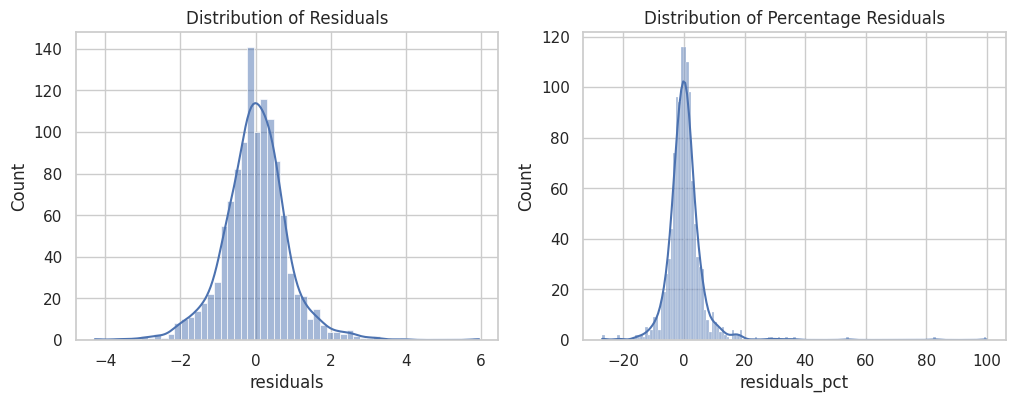

In [115]:
# Plot a histogram of the percentage residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

# plot a histplot on the first column
sns.histplot(data=main_results_df, x='residuals', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals')

# plot a histplot on the second column
sns.histplot(data=main_results_df, x='residuals_pct', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Percentage Residuals')

plt.show()

In [116]:
# Find results that are more than 10% of the actual
extreme_error_threshold = 10

main_extreme_results_df = main_results_df[np.abs(main_results_df['residuals_pct']) > extreme_error_threshold]

main_extreme_results_df.shape

(69, 4)

In [118]:
main_extreme_results_df['actual_bin'] = pd.cut(main_extreme_results_df['actual'], bins=[0, 5, 10, 20, 30, 40], duplicates='drop')

error_by_group = main_extreme_results_df.groupby('actual_bin')['residuals_pct'].agg(['mean', 'median', 'count'])
error_by_group


,mean,median,count
actual_bin,,,
"(0, 5]",12.667641,13.135071,37
"(5, 10]",-4.075644,-10.335588,15
"(10, 20]",7.136692,11.394336,15
"(20, 30]",10.454432,10.454432,1
"(30, 40]",12.558131,12.558131,1


In [119]:
extreme_errors = main_results_df[main_results_df['residuals_pct'].abs() > 10]

extreme_errors.sort_values(by='residuals_pct', ascending=False).head(10)


,actual,predicted,residuals,residuals_pct
2732,1.0,1.997806,0.997806,99.780595
14845,3.0,5.476248,2.476248,82.541593
2864,5.0,7.693843,2.693843,53.876867
3619,3.0,4.090495,1.090495,36.349821
12183,2.0,2.681606,0.681606,34.080279
9462,19.0,24.944893,5.944893,31.288910
2812,4.0,5.161440,1.161440,29.035997
2196,3.0,3.827051,0.827051,27.568364
2280,3.0,3.702273,0.702273,23.409096
11757,3.0,3.555718,0.555718,18.523939


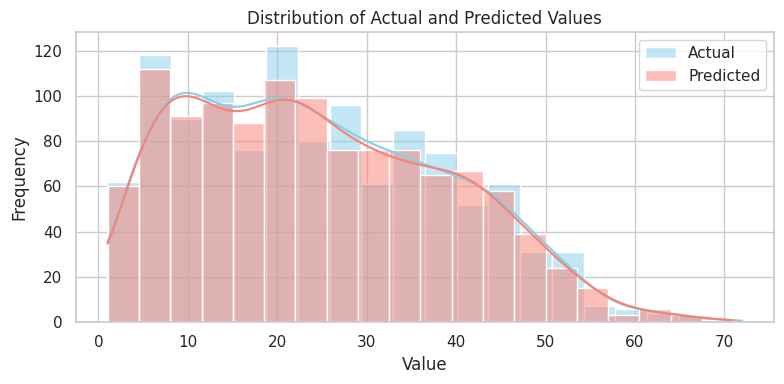

In [121]:
# Plot distrbutions of actual and predicted together
plt.figure(figsize=(8, 4))
sns.histplot(data=main_results_df['actual'], color='skyblue', label='Actual', bins=20, kde=True)
sns.histplot(data=main_results_df['predicted'], color='salmon', label='Predicted', bins=20, kde=True)
plt.title('Distribution of Actual and Predicted Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

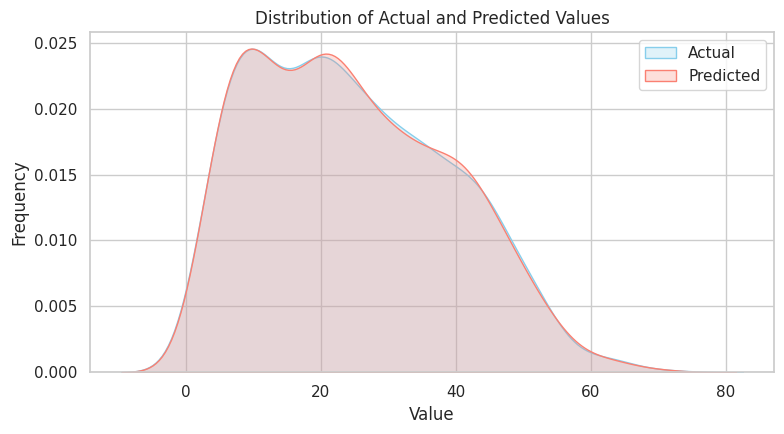

In [123]:
# Plot distrbutions of actual and predicted together
plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=main_results_df['actual'], color='skyblue', label='Actual', fill=True)
sns.kdeplot(data=main_results_df['predicted'], color='salmon', label='Predicted', fill=True)
plt.title('Distribution of Actual and Predicted Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [125]:
# Find rows with extreme results from X_test

problem_subset = X_test.loc[main_extreme_results_df.index]
problem_subset_target = y_test.loc[main_extreme_results_df.index]

problem_subset['calories'] = problem_subset_target

problem_subset.head()

,age,height,weight,duration,heart_rate,gender_male,calories
9213,48,176.0,74.0,1.0,81.0,0,4.0
14410,28,191.0,94.0,1.0,82.0,1,3.0
5304,33,175.0,77.0,3.0,81.0,1,7.0
12731,41,185.0,85.0,4.0,81.0,1,11.0
2883,71,189.0,95.0,5.0,77.0,1,20.0


In [126]:
problem_subset.gender_male.value_counts()

,count
gender_male,
1,54
0,15


In [127]:
problem_subset[problem_subset['calories'] < 10].head()

,age,height,weight,duration,heart_rate,gender_male,calories
9213,48,176.0,74.0,1.0,81.0,0,4.0
14410,28,191.0,94.0,1.0,82.0,1,3.0
5304,33,175.0,77.0,3.0,81.0,1,7.0
14749,70,150.0,59.0,1.0,80.0,1,4.0
1446,36,181.0,85.0,1.0,85.0,1,3.0


> An entry of a young male with age = 28, height = 166, weight = 66kg, heart rate = 72 bpm buring only 1 calorie in 2 mins doesn't seem plausible. This means there are still some erroneous data entries that need to be filtered off.

## Inspect Entries That Might Still be Implausible

### Calculate a Plausibility Score for Calories Burned


A commonly used formula for estimating calories burned:

$$
\text{Calories/min} = \frac{\text{MET} \times 3.5 \times \text{weight in kg}}{200}
$$

Where:

* MET = **Metabolic Equivalent of Task**

  * \~1.0 = resting
  * \~1.5–2.5 = standing or slow walking
  * \~3.5–5.0 = brisk walking
  * ≥6.0 = moderate-to-high activity

---

### **Estimate Expected Calories Burned**

Using the MET formula:

$$
\text{Calories} = \frac{\text{MET} \times 3.5 \times \text{weight} \times \text{duration}}{200}
$$



#### Compute a Plausibility Score:

$$
\text{Plausibility Score} = \frac{\text{actual calories}}{\text{expected calories}}
$$

Then interpret the score:

* **\~1.0** → plausible
* **< 0.5** → underburn (likely implausible)
* **> 1.5 or 2.0** → overburn (possibly exaggerated)

In [26]:
def estimate_MET(hr):
    if hr < 75:
        return 1.0   # Rest or very light movement
    elif hr < 85:
        return 2.0   # Light walking
    elif hr < 95:
        return 3.0   # Brisk walking, low-intensity cardio
    elif hr < 101:
        return 4.0   # Moderate cardio
    else:  # 101–106
        return 5.0   # Pushing into moderate-high zone


In [130]:
low_duration_cleaned['estimated_MET'] = low_duration_cleaned['heart_rate'].apply(estimate_MET)

# Apply the calorie burn formula
low_duration_cleaned['expected_calories'] = (low_duration_cleaned['estimated_MET'] * 3.5 * low_duration_cleaned['weight'] * low_duration_cleaned['duration']) / 200

# Compute plausibility
low_duration_cleaned['plausibility_score'] = low_duration_cleaned['calories'] / low_duration_cleaned['expected_calories']

low_duration_cleaned['calorie_flag'] = 'plausible'
low_duration_cleaned.loc[low_duration_cleaned['plausibility_score'] < 0.5, 'calorie_flag'] = 'too low'
low_duration_cleaned.loc[low_duration_cleaned['plausibility_score'] > 2.0, 'calorie_flag'] = 'too high'

low_duration_cleaned['calorie_flag'].value_counts()


,count
calorie_flag,
plausible,4376
too high,231
too low,42


In [131]:
low_duration_plausible = low_duration_cleaned[low_duration_cleaned['calorie_flag'] == 'plausible']
low_duration_plausible.shape


(4376, 13)

In [132]:
low_duration_plausible.describe()

,age,height,weight,duration,heart_rate,body_temp,calories,estimated_MET,expected_calories,plausibility_score
count,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000
mean,42.579982,175.505256,75.906536,5.904936,86.243830,37.863752,24.546161,2.687386,22.030332,1.183785
std,16.852693,13.606636,14.538609,2.761550,5.493369,0.402422,14.447704,0.623418,13.829774,0.347041
min,20.000000,132.000000,41.000000,1.000000,67.000000,37.100000,1.000000,1.000000,1.102500,0.510204
25%,28.000000,165.000000,64.000000,3.000000,82.000000,37.599719,12.000000,2.000000,10.675000,0.904159
50%,39.000000,175.000000,75.000000,6.000000,86.000000,37.599719,23.000000,3.000000,19.950000,1.169591
75%,55.000000,186.000000,87.000000,8.000000,90.000000,38.100000,35.000000,3.000000,31.080000,1.432904
max,79.000000,222.000000,132.000000,10.000000,106.000000,38.900000,73.000000,5.000000,86.625000,2.000000


## Train Model with only plausible data entries

In [134]:
# Drop age_group
low_duration_plausible.drop(columns=['age_group'], axis='columns', inplace=True)

# Encode Gender
low_d_df = pd.get_dummies(columns=['gender'], data=low_duration_plausible, drop_first=True)

# Convert bool values to int
low_d_df['gender_male'] = low_d_df['gender_male'].astype(int)

low_d_df.head(3)

,age,height,weight,duration,heart_rate,body_temp,calories,estimated_MET,expected_calories,plausibility_score,calorie_flag,gender_male
2,69,179.0,79.0,5.0,88.0,38.700000,26.0,3.0,20.7375,1.253767,plausible,1
4,27,154.0,58.0,10.0,81.0,37.599719,35.0,2.0,20.3000,1.724138,plausible,0
14,53,182.0,85.0,2.0,82.0,38.100000,7.0,2.0,5.9500,1.176471,plausible,1


### Feature Engineering

In [31]:
# Multiply duration by heart_rate, store as cardio_load
low_d_df['cardio_load'] = low_d_df['heart_rate'] * low_d_df['duration']

# Multiply age by duration, store as age_by_duration
low_d_df['age_by_duration'] = low_d_df['age'] * low_d_df['duration']

# Calculate mass_ratio (weight/height, use height in cm)
low_d_df['mass_ratio'] = low_d_df['weight'] / low_d_df['height']

In [32]:
cols_to_use = ['age', 'height', 'weight', 'duration', 'heart_rate', 'gender_male', 'cardio_load', 'mass_ratio']

# Create X and Y
X = low_d_df[cols_to_use]
y = low_d_df['calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12)


In [422]:
print([X_train.shape, X_test.shape])

[(3282, 8), (1094, 8)]


### Model Training

In [36]:
from xgboost import XGBRegressor

In [423]:
# Train an XGBoost model

main_xgb = XGBRegressor(n_estimators=120, max_depth=6, learning_rate=0.135, random_state=42)

main_xgb.fit(X_train, y_train)

train_score = main_xgb.score(X_train, y_train)
test_score = main_xgb.score(X_test, y_test)

print(f"Train Score: {round(train_score, 3)}\n")
print(f"Test Score: {round(test_score, 3)}\n")

# Evaluate XGBoost Regressor with MSE, RMSE and R2 Score
y_pred = main_xgb.predict(X_test)

xgb_mse = mean_squared_error(y_test, y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred)

print(f"R2 Score: {round(xgb_r2, 3)}, MSE: {round(xgb_mse, 3)}, RMSE: {round(xgb_rmse, 3)}")

Train Score: 0.999

Test Score: 0.997

R2 Score: 0.997, MSE: 0.649, RMSE: 0.806


### Error Analysis

In [397]:
# Error Analysis for the XGBoost model
y_pred = main_xgb.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals*100)/y_test

# Create a df
plausible_results_df = pd.DataFrame({'actual': y_test,
                           'predicted': y_pred,
                           'residuals': residuals,
                           'residuals_pct': residuals_pct})

plausible_results_df[['residuals', 'residuals_pct']].describe()

,residuals,residuals_pct
count,1094.000000,1094.000000
mean,-0.004171,0.215481
std,0.806036,4.690661
min,-4.572899,-29.673737
25%,-0.414931,-2.143780
50%,0.008430,0.034887
75%,0.412453,2.080608
max,5.010708,36.979103


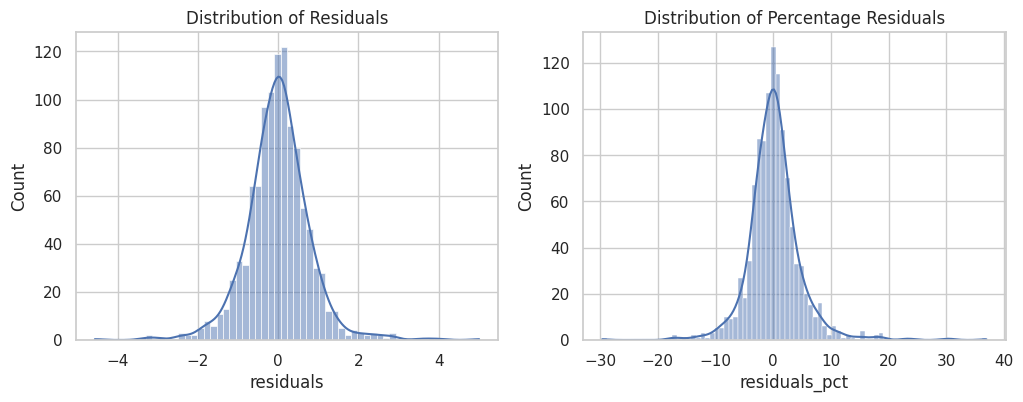

In [379]:
# Plot a histogram of the percentage residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

# plot a histplot on the first column
sns.histplot(data=plausible_results_df, x='residuals', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals')

# plot a histplot on the second column
sns.histplot(data=plausible_results_df, x='residuals_pct', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Percentage Residuals')

plt.show()

In [398]:
# Find results that are more than 10% of the actual
extreme_error_threshold = 10

plausible_extreme_results_df = plausible_results_df[np.abs(plausible_results_df['residuals_pct']) > extreme_error_threshold]

print(f"{plausible_extreme_results_df.shape[0]} rows have > 10% error \n")
print(f"{round((plausible_extreme_results_df.shape[0]/X_test.shape[0])*100, 2)}% of the test data showed > 10% error")

43 rows have > 10% error 

3.93% of the test data showed > 10% error


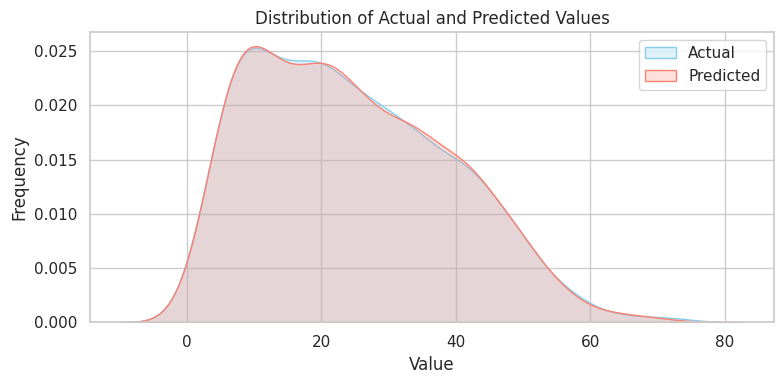

In [399]:
# Plot distrbutions of actual and predicted together
plt.figure(figsize=(8, 4))
sns.kdeplot(data=plausible_results_df['actual'], color='skyblue', label='Actual', fill=True)
sns.kdeplot(data=plausible_results_df['predicted'], color='salmon', label='Predicted', fill=True)
plt.title('Distribution of Actual and Predicted Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [400]:
extreme_errors = plausible_results_df[plausible_results_df['residuals_pct'].abs() > 10]

extreme_errors.sort_values(by='residuals_pct', ascending=False).head(10)


,actual,predicted,residuals,residuals_pct
2812,4.0,5.479164,1.479164,36.979103
5206,3.0,3.919004,0.919004,30.633473
7338,2.0,2.599179,0.599179,29.958963
4815,6.0,7.422071,1.422071,23.701175
7108,9.0,11.079668,2.079668,23.107423
3307,3.0,3.567318,0.567318,18.910607
9462,19.0,22.529341,3.529341,18.575478
2942,7.0,8.285422,1.285422,18.363176
5710,3.0,3.535949,0.535949,17.864966
11753,3.0,3.528963,0.528963,17.632087


In [401]:
plausible_results_df['actual_bin'] = pd.cut(plausible_results_df['actual'], bins=[0, 5, 10, 20, 30, 40, 50, 60, 70, 80], duplicates='drop')

error_by_group = plausible_results_df.groupby('actual_bin')['residuals_pct'].agg(['mean', 'median', 'count'])
error_by_group


,mean,median,count
actual_bin,,,
"(0, 5]",0.370233,0.527459,68
"(5, 10]",0.926386,0.696635,159
"(10, 20]",0.373740,0.126787,270
"(20, 30]",0.000112,0.033885,231
"(30, 40]",0.372895,0.175409,181
"(40, 50]",-0.375681,-0.225101,137
"(50, 60]",-0.880804,-0.442116,39
"(60, 70]",-1.451102,-1.221030,6
"(70, 80]",-3.546199,-2.742439,3


### Key Observations
🔹 **Majority of predictions are accurate**
- For most bins (0–50), mean and median residuals are small (±1 or less).

- **Signs of improvement:**

  - Mean and median residuals in (10–20], (20–30], (30–40] are near zero, meaning that the model is unbiased in this range.

  - Even in (5–10], mean = 0.92 and median = 0.69, which is reasonable.


🔹 **Performance degrades on very high values**
- Bins (60–70] and (70–80] show negative bias, i.e., under-prediction:

- Mean residual = −1.4 to −3.5

- But they contain only 6 and 3 samples, respectively.

> ⚠️ With so few samples, this is not a model weakness, but likely data sparsity.

# Treat Subset for Duration Greater Than 10

In [321]:
duration_more_than_10.shape

(10126, 9)

In [402]:
duration_more_than_10.describe()

,age,height,weight,duration,heart_rate,body_temp,calories
count,10126.000000,10126.000000,10126.000000,10126.000000,10126.000000,10126.000000,10126.000000
mean,42.805945,174.475015,75.010271,20.204819,100.125321,40.463579,121.027948
std,16.995080,14.251412,15.031920,5.629334,7.433870,0.355187,51.269163
min,20.000000,126.000000,38.000000,11.000000,77.000000,39.300000,13.000000
25%,28.000000,164.000000,63.000000,15.000000,95.000000,40.200000,78.000000
50%,39.000000,175.000000,74.000000,20.000000,100.000000,40.500000,115.000000
75%,56.000000,185.000000,87.000000,25.000000,105.000000,40.700000,159.000000
max,79.000000,219.000000,126.000000,30.000000,128.000000,41.500000,314.000000


> Ignore `body_temp` because it contains unrealistic data.

## Filter off implausible entries using MET estimations

In [43]:
def estimate_MET(hr):
    if hr < 80:
        return 1.5   # Light movement, warm-up
    elif hr < 90:
        return 2.5   # Light walking or stretching
    elif hr < 100:
        return 4.0   # Brisk walking or light cardio
    elif hr < 110:
        return 5.5   # Moderate effort
    elif hr < 120:
        return 7.0   # Moderate-high intensity
    else:  # HR 120–128
        return 8.0   # Vigorous sustained cardio


In [405]:
duration_more_than_10['estimated_MET'] = duration_more_than_10['heart_rate'].apply(estimate_MET)

# Apply the calorie burn formula
duration_more_than_10['expected_calories'] = (duration_more_than_10['estimated_MET'] * 3.5 * duration_more_than_10['weight'] * duration_more_than_10['duration']) / 200

# Compute plausibility
duration_more_than_10['plausibility_score'] = duration_more_than_10['calories'] / duration_more_than_10['expected_calories']

duration_more_than_10['calorie_flag'] = 'plausible'
duration_more_than_10.loc[duration_more_than_10['plausibility_score'] < 0.5, 'calorie_flag'] = 'too low'
duration_more_than_10.loc[duration_more_than_10['plausibility_score'] > 2.0, 'calorie_flag'] = 'too high'

duration_more_than_10['calorie_flag'].value_counts()


,count
calorie_flag,
plausible,10092
too high,32
too low,2


In [406]:
high_duration_plausible = duration_more_than_10[duration_more_than_10['calorie_flag'] == 'plausible']
high_duration_plausible.shape


(10092, 13)

## Train model for high duration (> 10)

In [407]:
# Encode Gender
high_d_df = pd.get_dummies(columns=['gender'], data=high_duration_plausible, drop_first=True)

# Convert bool values to int
high_d_df['gender_male'] = high_d_df['gender_male'].astype(int)

high_d_df.head(3)

,age,height,weight,duration,heart_rate,body_temp,calories,age_group,estimated_MET,expected_calories,plausibility_score,calorie_flag,gender_male
0,68,190.0,94.0,29.0,105.0,40.8,231.0,60–69,5.5,262.37750,0.880411,plausible,1
1,20,166.0,60.0,14.0,94.0,40.3,66.0,20–29,4.0,58.80000,1.122449,plausible,0
3,34,179.0,71.0,13.0,100.0,40.5,71.0,30–39,5.5,88.83875,0.799201,plausible,0


### Feature Engineering

In [47]:
# Multiply duration by heart_rate, store as cardio_load
high_d_df['cardio_load'] = high_d_df['heart_rate'] * high_d_df['duration']

# Multiply age by duration, store as age_by_duration
#high_d_df['age_by_duration'] = high_d_df['age'] * high_d_df['duration']

# Calculate mass_ratio (weight/height, use height in cm)
high_d_df['mass_ratio'] = high_d_df['weight'] / high_d_df['height']

In [409]:
cols_to_use = ['age', 'height', 'weight', 'duration', 'heart_rate', 'gender_male', 'cardio_load', 'mass_ratio']

# Create X and Y
X = high_d_df[cols_to_use]
y = high_d_df['calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12)

print([X_train.shape, X_test.shape])


[(7569, 8), (2523, 8)]


### Model Training

In [ ]:
# Train an XGBoost model

#main_xgb = XGBRegressor(n_estimators=125, max_depth=6, learning_rate=0.158)
main_xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.159)

main_xgb.fit(X_train, y_train)

train_score = main_xgb.score(X_train, y_train)
test_score = main_xgb.score(X_test, y_test)

print(f"Train Score: {round(train_score, 3)}\n")
print(f"Test Score: {round(test_score, 3)}\n")

# Evaluate XGBoost Regressor with MSE, RMSE and R2 Score
y_pred = main_xgb.predict(X_test)

xgb_mse = mean_squared_error(y_test, y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred)

print(f"R2 Score: {round(xgb_r2, 3)}, MSE: {round(xgb_mse, 3)}, RMSE: {round(xgb_rmse, 3)}")

Train Score: 0.999

Test Score: 0.998

R2 Score: 0.998, MSE: 4.278, RMSE: 2.068


### Error Analysis

In [411]:
# Error Analysis for the XGBoost model
y_pred = main_xgb.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals*100)/y_test

# Create a df
high_duration_results = pd.DataFrame({'actual': y_test,
                           'predicted': y_pred,
                           'residuals': residuals,
                           'residuals_pct': residuals_pct})

high_duration_results[['residuals', 'residuals_pct']].describe()

,residuals,residuals_pct
count,2523.000000,2523.000000
mean,0.023451,0.105076
std,2.068654,1.889830
min,-21.396118,-7.252921
25%,-1.046829,-0.946131
50%,0.015335,0.013917
75%,1.138790,1.076337
max,11.920731,16.284222


In [412]:
high_duration_results[np.abs(high_duration_results['residuals']) > 10]

,actual,predicted,residuals,residuals_pct
13480,264.0,248.906784,-15.093216,-5.717127
10806,256.0,244.673920,-11.326080,-4.424250
11272,171.0,182.920731,11.920731,6.971187
13871,295.0,273.603882,-21.396118,-7.252921


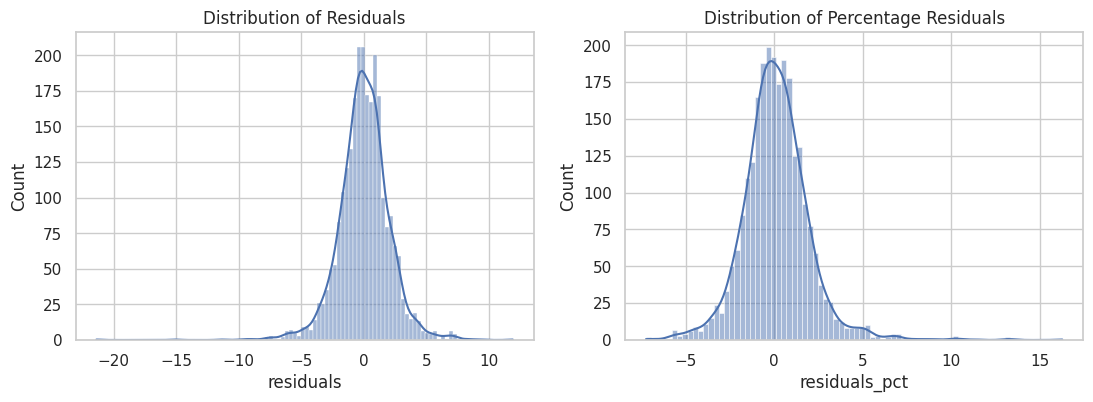

In [413]:
# Plot a histogram of the percentage residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes = axes.flatten()

# plot a histplot on the first column
sns.histplot(data=high_duration_results, x='residuals', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals')

# plot a histplot on the second column
sns.histplot(data=high_duration_results, x='residuals_pct', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Percentage Residuals')

plt.show()

In [414]:
# Find results that are more than 10% of the actual
extreme_error_threshold = 10

high_duration_extreme_results = high_duration_results[np.abs(high_duration_results['residuals_pct']) > extreme_error_threshold]

print(f"{high_duration_extreme_results.shape[0]} rows have > 10% error \n")
print(f"{round((high_duration_extreme_results.shape[0]/X_test.shape[0])*100, 2)}% of the test data showed > 10% error")


7 rows have > 10% error 

0.28% of the test data showed > 10% error


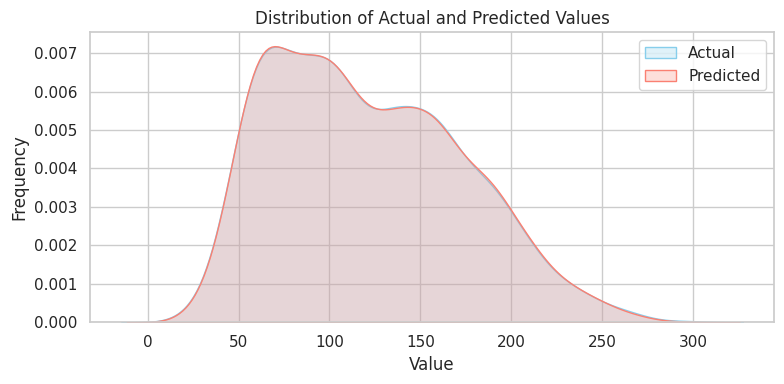

In [415]:
# Plot distrbutions of actual and predicted together
plt.figure(figsize=(8, 4))
sns.kdeplot(data=high_duration_results['actual'], color='skyblue', label='Actual', fill=True)
sns.kdeplot(data=high_duration_results['predicted'], color='salmon', label='Predicted', fill=True)
plt.title('Distribution of Actual and Predicted Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [416]:
extreme_errors = high_duration_results[np.abs(high_duration_results['residuals_pct']) > 10]

extreme_errors.sort_values(by='residuals_pct', ascending=False)


,actual,predicted,residuals,residuals_pct
7770,18.0,20.931160,2.931160,16.284222
2193,71.0,80.451378,9.451378,13.311800
7939,48.0,54.358776,6.358776,13.247450
12353,48.0,53.442833,5.442833,11.339235
14524,27.0,29.788700,2.788700,10.328519
1791,68.0,74.938339,6.938339,10.203440
7461,28.0,30.856638,2.856638,10.202278


In [417]:
high_duration_results['actual_bin'] = pd.cut(high_duration_results['actual'], bins=[10, 20, 30, 40, 50, 100, 200, 320], duplicates='drop')

error_by_group = high_duration_results.groupby('actual_bin')['residuals_pct'].agg(['mean', 'median', 'count'])
error_by_group


,mean,median,count
actual_bin,,,
"(10, 20]",16.284222,16.284222,1
"(20, 30]",2.789883,-0.051621,11
"(30, 40]",0.811969,0.582028,26
"(40, 50]",0.747948,0.574094,98
"(50, 100]",0.141131,0.085106,897
"(100, 200]",0.058763,0.013246,1294
"(200, 320]",-0.402601,-0.281929,196


## Key Observations
- Most common ranges (50–200 kcal): residuals are very small which means excellent generalization

- Slight underprediction in high-calorie bin (200–320), but still <0.5 kcal average error which isn't critical

- Low-count bins (10–30 kcal) have worse means, which isn't surprising due to tiny sample size.

- No signs of bias or skew across the distribution.